# BECCS NPV simulation

Run the BECCS electricity Monte Carlo simulation and visualize its NPV and levelized-net-margin distributions. The summary also reports LCOE and the number and share of simulations with non-negative versus negative NPV.

Negative BECCS emissions create a negative `annual_emissions_cost_eur`; subtracting that value makes the carbon term a revenue in the shared cash-flow formula.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_electricity_results,
)

from npv_summary import summarize_metric_signs


In [2]:
TECHNOLOGY = 'beccs'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

results_by_technology = simulate_electricity_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,lifetime_years,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,...,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_mwh,present_value_total_cost_eur,lcoe_eur_per_mwh,levelized_net_margin_eur_per_mwh
0,0,beccs,1000000.0,7665.0,25.0,130.463144,130463.144162,3368.514785,167.975051,1.501061,...,1.501061e+06,1.286579e+08,-1.017538e+08,5.031974e+07,4.375026e+07,2.755724e+07,1.067478e+07,9.766190e+08,91.488472,2.581528
1,1,beccs,1000000.0,7665.0,25.0,130.463144,130463.144162,2993.179093,140.673390,2.275629,...,2.275629e+06,1.357277e+08,-1.000215e+08,5.633455e+07,3.773545e+07,1.231793e+07,1.067478e+07,9.918583e+08,92.916071,1.153929
2,2,beccs,1000000.0,7665.0,25.0,130.463144,130463.144162,3276.571227,162.867779,1.399500,...,1.399500e+06,6.549793e+07,-9.295329e+07,-4.807618e+06,9.887762e+07,6.280247e+08,1.067478e+07,3.761515e+08,35.237417,58.832583
3,3,beccs,1000000.0,7665.0,25.0,130.463144,130463.144162,2971.438231,217.285500,1.259955,...,1.259955e+06,5.446175e+07,-1.002216e+08,-1.615216e+07,1.102222e+08,7.889337e+08,1.067478e+07,2.152425e+08,20.163655,73.906345
4,4,beccs,1000000.0,7665.0,25.0,130.463144,130463.144162,4012.587672,204.000215,1.944917,...,1.944917e+06,8.166151e+07,-8.724830e+07,2.297264e+07,7.109736e+07,2.354536e+08,1.067478e+07,7.687226e+08,72.012995,22.057005


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcoe_eur_per_mwh = results["lcoe_eur_per_mwh"]
levelized_net_margin_eur_per_mwh = results["levelized_net_margin_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcoe_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOE EUR/MWh"
        ),
        levelized_net_margin_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "Levelized net margin EUR/MWh"
        ),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOE EUR/MWh,Levelized net margin EUR/MWh
count,100000.000000,100000.000000,100000.000000
mean,361.488143,60.206232,33.863768
std,227.631336,21.324226,21.324226
min,-504.774438,-5.658224,-47.286653
5%,-32.105716,26.668615,-3.007624
50%,372.098228,59.212292,34.857708
95%,719.494697,97.077624,67.401385
max,1064.576473,141.356653,99.728224


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),93419,0.93419
1,Negative (NPV < 0),6581,0.06581


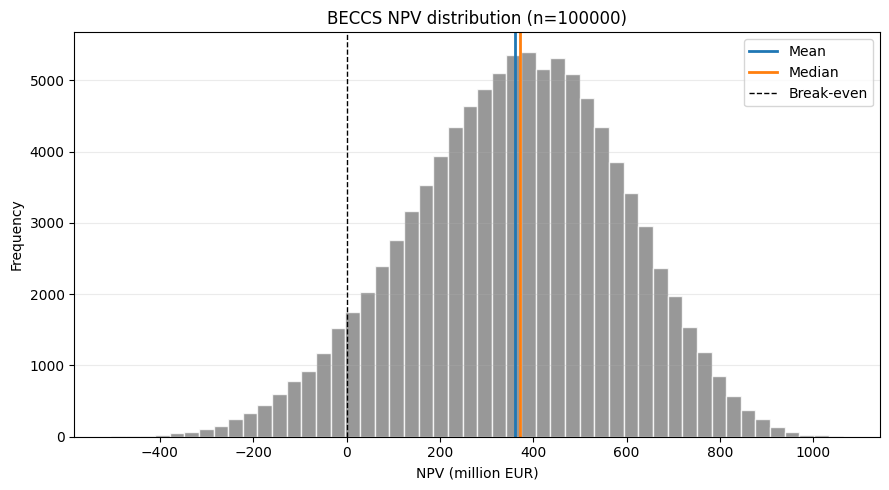

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"BECCS NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

## Levelized net margin histogram

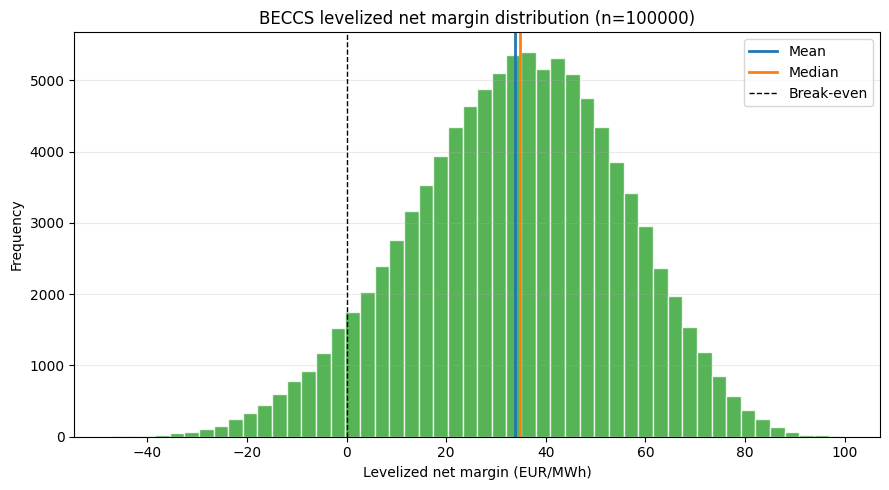

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    levelized_net_margin_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    levelized_net_margin_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"BECCS levelized net margin distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("Levelized net margin (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur        23.306217
annual_variable_opex_eur      1.735588
annual_fuel_cost_eur         87.826522
annual_emissions_cost_eur   -93.558787
annual_net_cash_flow_eur     74.760460
Name: Mean annual value, million EUR, dtype: float64